In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve as linsolve
import csv
import pandas as pd


SAVING NODE DISPLACEMENTS TO CSV
Node displacement data saved to 'p5_grok.csv'

CSV文件包含 16 个节点的数据

前10个节点的数据:
 Node Node_Coord       X      Y   Z  Fixed       U1        U2  U3  UR1  UR2       UR3  Total_Displacement
    1      (1,1)     0.0    0.0 0.0      1 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    2      (2,1)  6000.0    0.0 0.0      1 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    3      (3,1) 12000.0    0.0 0.0      1 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    4      (4,1) 18000.0    0.0 0.0      1 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    5      (1,2)     0.0 3000.0 0.0      0 2.557318  0.021996 0.0  0.0  0.0 -0.000906            2.557412
    6      (2,2)  6000.0 3000.0 0.0      0 2.514921 -0.002580 0.0  0.0  0.0 -0.000690            2.514922
    7      (3,2) 12000.0 3000.0 0.0      0 2.485549  0.002444 0.0  0.0  0.0 -0.000686            2.485550
    8      (4,2) 18000.0 3000.0 0.0      

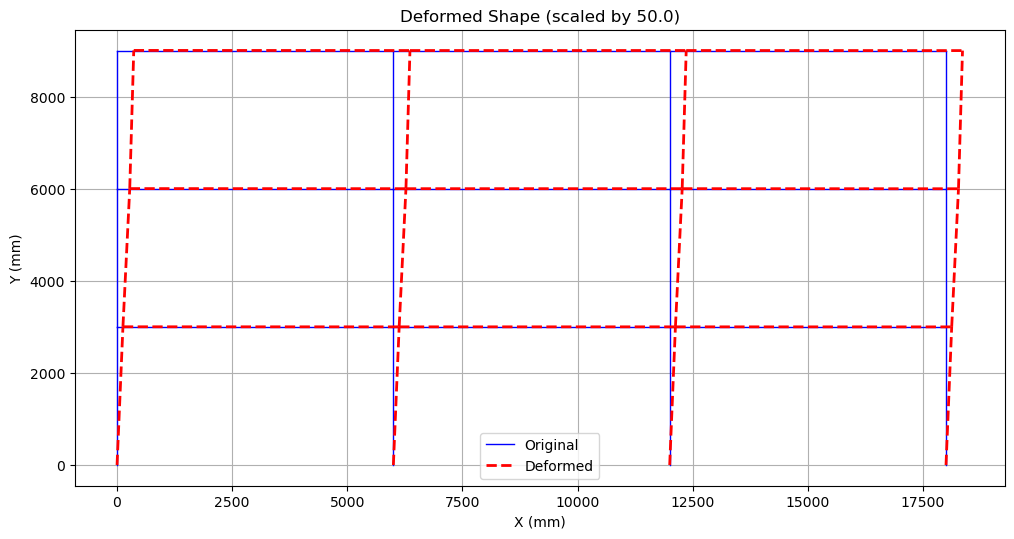

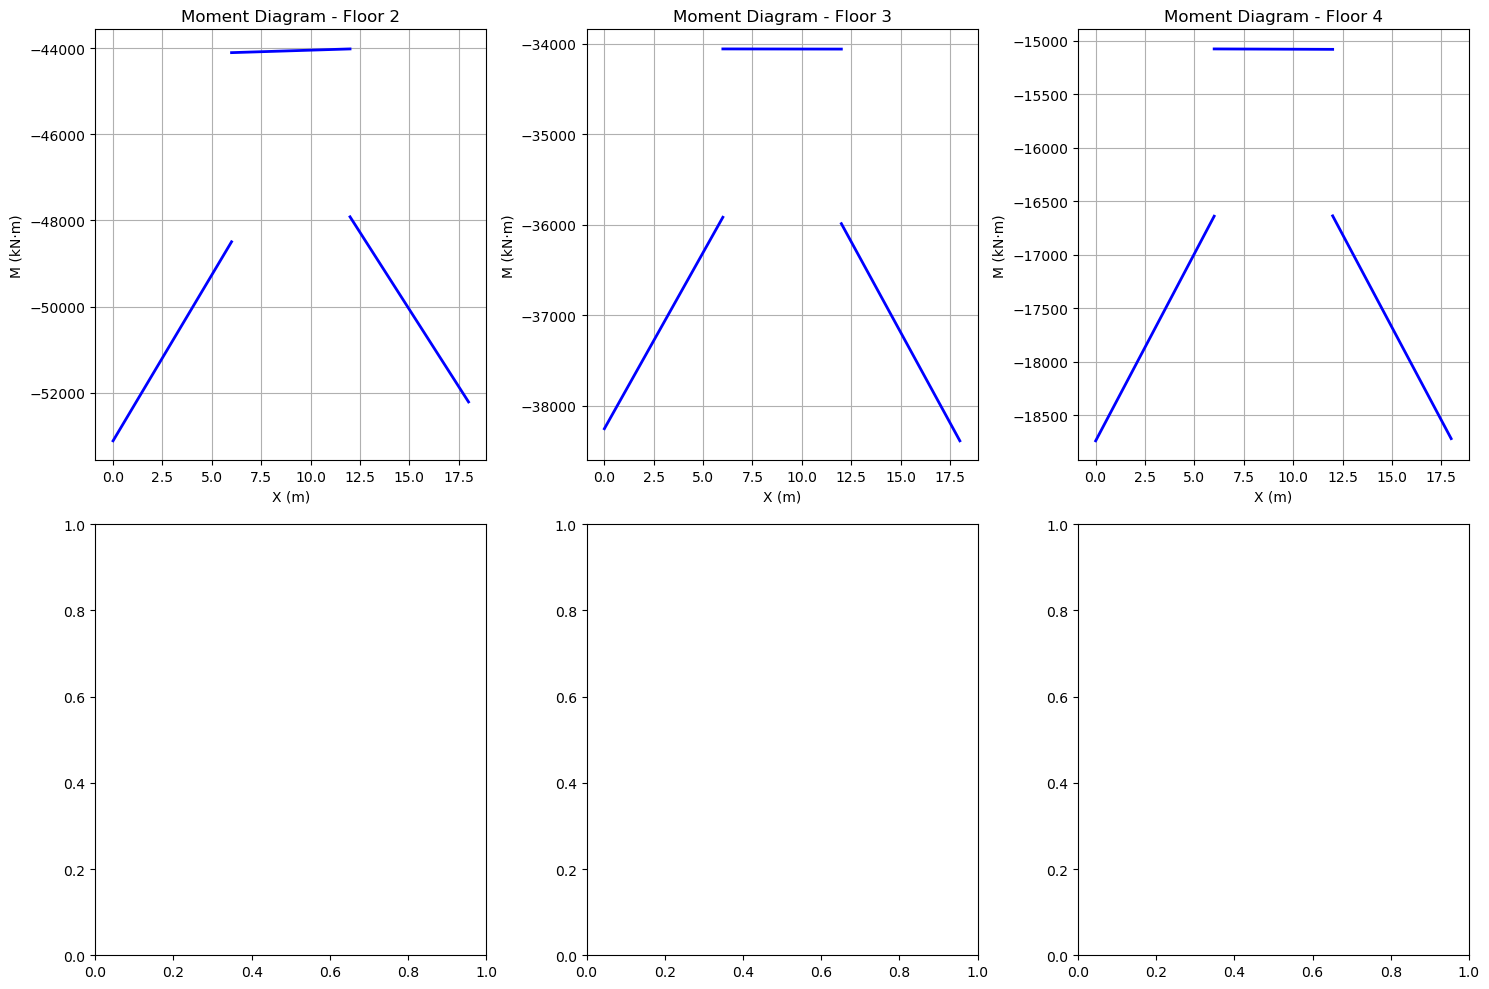

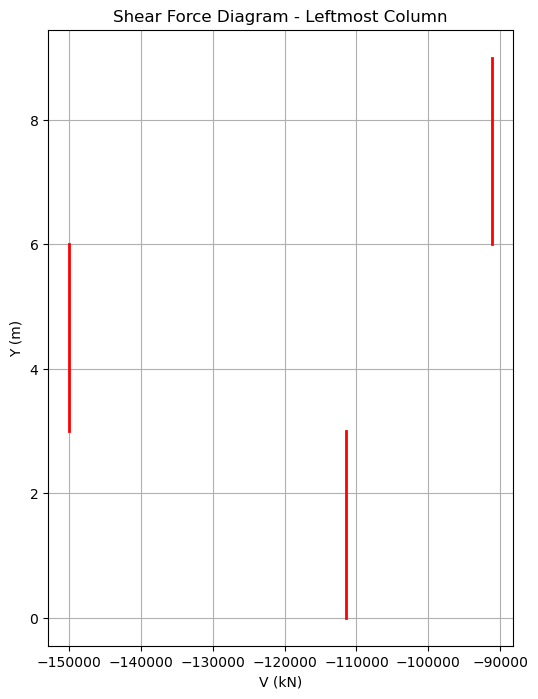

In [4]:
# Material and section properties
E = 3.0e4  # MPa (N/mm²)
nu = 0.3
A = 400.0 * 400.0  # mm²
I = 400.0 * (400.0)**3 / 12.0  # mm⁴
G = E / (2.0 * (1.0 + nu))  # MPa, but not used since Euler-Bernoulli (shear neglected as slenderness ~7.5-15, approximate)

# Node coordinates (16 nodes, 0-based indexing: id = j*4 + i, j=0 bottom to 3 top, i=0 left to 3 right)
x_pos = np.array([0.0, 6000.0, 12000.0, 18000.0])
y_pos = np.array([0.0, 3000.0, 6000.0, 9000.0])
nodes = np.zeros((16, 2))
for j in range(4):
    for i in range(4):
        idx = j * 4 + i
        nodes[idx] = [x_pos[i], y_pos[j]]

# Elements: list of (node1_id, node2_id), 0-based
elements = []
# Columns (12 vertical)
for i in range(4):
    for j in range(3):
        n1 = j * 4 + i
        n2 = (j + 1) * 4 + i
        elements.append((n1, n2))
# Beams (9 horizontal)
for j in range(1, 4):
    for i in range(3):
        n1 = j * 4 + i
        n2 = j * 4 + i + 1
        elements.append((n1, n2))
assert len(elements) == 21

# Degrees of freedom
n_dof = 16 * 3  # 48 total
fixed_nodes = [0, 1, 2, 3]  # bottom row
fixed_dofs = []
for node in fixed_nodes:
    fixed_dofs.extend([3 * node, 3 * node + 1, 3 * node + 2])
free_dofs = [d for d in range(n_dof) if d not in fixed_dofs]
assert len(fixed_dofs) == 12 and len(free_dofs) == 36

# Function to compute 2D frame element stiffness matrix (Euler-Bernoulli)
def element_stiffness(n1, n2, nodes, E, A, I):
    p1 = nodes[n1]
    p2 = nodes[n2]
    L = np.linalg.norm(p2 - p1)
    if L < 1e-6:
        return np.zeros((6, 6))
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    c, s = dx / L, dy / L
    # Rotation matrix R for (ux, uy, θz) -> (u_local, v_local, θ_local)
    R = np.array([[c, s, 0.0],
                  [-s, c, 0.0],
                  [0.0, 0.0, 1.0]])
    T = np.block([[R, np.zeros((3, 3))],
                  [np.zeros((3, 3)), R]])
    # Local stiffness kl (6x6)
    kl = np.zeros((6, 6))
    # Axial
    ae_l = A * E / L
    kl[0, 0] = ae_l
    kl[0, 3] = -ae_l
    kl[3, 0] = -ae_l
    kl[3, 3] = ae_l
    # Bending (Euler-Bernoulli)
    ei_l3 = E * I / L**3
    ei_l2 = E * I / L**2
    ei_l = E * I / L
    kl[1, 1] = 12.0 * ei_l3
    kl[1, 2] = 6.0 * ei_l2
    kl[1, 4] = -12.0 * ei_l3
    kl[1, 5] = 6.0 * ei_l2
    kl[2, 1] = 6.0 * ei_l2
    kl[2, 2] = 4.0 * ei_l
    kl[2, 4] = -6.0 * ei_l2
    kl[2, 5] = 2.0 * ei_l
    kl[4, 1] = -12.0 * ei_l3
    kl[4, 2] = -6.0 * ei_l2
    kl[4, 4] = 12.0 * ei_l3
    kl[4, 5] = -6.0 * ei_l2
    kl[5, 1] = 6.0 * ei_l2
    kl[5, 2] = 2.0 * ei_l
    kl[5, 4] = -6.0 * ei_l2
    kl[5, 5] = 4.0 * ei_l
    # Global element stiffness
    ke = T.T @ kl @ T
    return ke

# Assemble global stiffness
K = np.zeros((n_dof, n_dof))
for n1, n2 in elements:
    dofs = [3 * n1, 3 * n1 + 1, 3 * n1 + 2,
            3 * n2, 3 * n2 + 1, 3 * n2 + 2]
    ke = element_stiffness(n1, n2, nodes, E, A, I)
    K[np.ix_(dofs, dofs)] += ke

# Load vector (50 kN = 50000 N horizontal at nodes (1,2), (1,3), (1,4) -> ids 4,8,12)
F = np.zeros(n_dof)
loaded_node_ids = [4, 8, 12]  # 0-based
for nid in loaded_node_ids:
    F[3 * nid] = 50000.0  # ux direction

# Apply BC: solve reduced system
K_red = K[np.ix_(free_dofs, free_dofs)]
F_red = F[free_dofs]
u_red = linsolve(K_red, F_red)
u = np.zeros(n_dof)
u[free_dofs] = u_red

# ============================================
# 保存节点位移结果到CSV文件
# ============================================
print("\n" + "="*60)
print("SAVING NODE DISPLACEMENTS TO CSV")
print("="*60)

# 创建数据列表
node_data = []

for nid in range(16):  # 0-based节点编号
    node_id = nid + 1  # 从1开始编号
    x = nodes[nid][0]
    y = nodes[nid][1]
    z = 0.0  # 2D结构，Z坐标为0
    
    # 获取位移和转角
    ux = u[3 * nid]         # U1 (mm)
    uy = u[3 * nid + 1]     # U2 (mm)
    uz = 0.0                # U3 (mm) - 2D结构为0
    ur1 = 0.0               # UR1 (rad) - 2D结构为0
    ur2 = 0.0               # UR2 (rad) - 2D结构为0
    ur3 = u[3 * nid + 2]    # UR3 (rad)
    
    # 计算总位移（2D平面）
    total_displacement = np.sqrt(ux**2 + uy**2)
    
    # 检查是否为固定节点
    is_fixed = 1 if nid in fixed_nodes else 0
    
    # 获取节点坐标索引 (i, j) 从1开始计数
    j = nid // 4  # 行索引 (0-based)
    i = nid % 4   # 列索引 (0-based)
    
    # 添加到数据列表
    node_data.append({
        'Node': node_id,
        'Node_Coord': f"({i+1},{j+1})",  # 从1开始计数
        'X': x,
        'Y': y,
        'Z': z,
        'Fixed': is_fixed,
        'U1': ux,
        'U2': uy,
        'U3': uz,
        'UR1': ur1,
        'UR2': ur2,
        'UR3': ur3,
        'Total_Displacement': total_displacement
    })

# 按节点编号排序
node_data.sort(key=lambda x: x['Node'])

# 保存到CSV文件
csv_filename = "p5_grok.csv"
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Node', 'Node_Coord', 'X', 'Y', 'Z', 'Fixed', 'U1', 'U2', 'U3', 'UR1', 'UR2', 'UR3', 'Total_Displacement']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in node_data:
        writer.writerow(data)

print(f"Node displacement data saved to '{csv_filename}'")

# 使用pandas读取并显示部分数据以供验证
df = pd.read_csv(csv_filename)
print(f"\nCSV文件包含 {len(df)} 个节点的数据")
print("\n前10个节点的数据:")
print(df.head(10).to_string(index=False))

# 显示统计信息
print("\n位移统计信息:")
print(f"最大水平位移 (U1): {df['U1'].abs().max():.6f} mm (节点 {df.loc[df['U1'].abs().idxmax(), 'Node']})")
print(f"最大竖向位移 (U2): {df['U2'].abs().max():.6f} mm (节点 {df.loc[df['U2'].abs().idxmax(), 'Node']})")
print(f"最大转角 (UR3): {df['UR3'].abs().max():.6f} rad (节点 {df.loc[df['UR3'].abs().idxmax(), 'Node']})")
print(f"最大总位移: {df['Total_Displacement'].max():.6f} mm (节点 {df.loc[df['Total_Displacement'].idxmax(), 'Node']})")

# 显示固定节点的位移信息
fixed_data = df[df['Fixed'] == 1]
if len(fixed_data) > 0:
    print(f"\n固定节点编号: {fixed_data['Node'].tolist()}")
    print("固定节点的位移 (应为0或接近0):")
    print(fixed_data[['Node', 'Node_Coord', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 显示自由节点的最大位移
free_data = df[df['Fixed'] == 0]
if len(free_data) > 0:
    print(f"\n自由节点中位移最大的5个节点:")
    top_5 = free_data.nlargest(5, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    print(top_5.to_string(index=False))

# 可选：创建更详细的报告文件
report_filename = "displacement_report_2.txt"
with open(report_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("NODE DISPLACEMENT ANALYSIS REPORT (Code 2)\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Analysis Parameters:\n")
    f.write(f"- Number of nodes: 16\n")
    f.write(f"- Number of elements: 21\n")
    f.write(f"- Applied load: 50 kN at nodes {loaded_node_ids}\n")
    f.write(f"- Material: E = {E:.0f} MPa, A = {A:.0f} mm², I = {I:.2e} mm⁴\n\n")
    
    f.write("Displacement Summary:\n")
    f.write(f"- Maximum horizontal displacement: {df['U1'].abs().max():.6f} mm\n")
    f.write(f"- Maximum vertical displacement: {df['U2'].abs().max():.6f} mm\n")
    f.write(f"- Maximum rotation: {df['UR3'].abs().max():.6f} rad ({np.degrees(df['UR3'].abs().max()):.4f} deg)\n")
    f.write(f"- Maximum total displacement: {df['Total_Displacement'].max():.6f} mm\n\n")
    
    f.write("Top 10 nodes with largest total displacements:\n")
    top_10 = df.nlargest(10, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    f.write(top_10.to_string(index=False) + "\n\n")
    
    f.write("Fixed nodes (bottom row):\n")
    f.write(fixed_data[['Node', 'Node_Coord']].to_string(index=False) + "\n\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("End of Report\n")
    f.write("="*80 + "\n")

print(f"\n详细报告已保存到 '{report_filename}'")

# ============================================
# 继续原有代码
# ============================================

# Nodal displacements and rotations (ux, uy, θz in mm, rad)
print("\n" + "="*60)
print("Nodal Displacements and Rotations (selected free nodes):")
print("="*60)
for j in range(1, 4):  # upper floors
    for i in range(4):
        nid = j * 4 + i
        ux = u[3 * nid]
        uy = u[3 * nid + 1]
        theta = u[3 * nid + 2]
        print(f"Node ({i+1},{j+1}): ux={ux:.4f} mm, uy={uy:.4f} mm, θz={np.degrees(theta):.4f} deg")

# Function to compute element end forces (N tension+, V shear in local y at end1, M at ends)
def element_end_forces(n1, n2, u, nodes, E, A, I):
    p1 = nodes[n1]
    p2 = nodes[n2]
    L = np.linalg.norm(p2 - p1)
    if L < 1e-6:
        return np.zeros(6)
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    c, s = dx / L, dy / L
    R = np.array([[c, s, 0.0],
                  [-s, c, 0.0],
                  [0.0, 0.0, 1.0]])
    T = np.block([[R, np.zeros((3, 3))],
                  [np.zeros((3, 3)), R]])
    u_elem = np.array([u[3 * n1], u[3 * n1 + 1], u[3 * n1 + 2],
                       u[3 * n2], u[3 * n2 + 1], u[3 * n2 + 2]])
    u_local = T.T @ u_elem
    # Local kl (same as in stiffness)
    ae_l = A * E / L
    ei_l3 = E * I / L**3
    ei_l2 = E * I / L**2
    ei_l = E * I / L
    kl = np.zeros((6, 6))
    kl[0, 0] = ae_l; kl[0, 3] = -ae_l
    kl[3, 0] = -ae_l; kl[3, 3] = ae_l
    kl[1, 1] = 12.0 * ei_l3; kl[1, 2] = 6.0 * ei_l2; kl[1, 4] = -12.0 * ei_l3; kl[1, 5] = 6.0 * ei_l2
    kl[2, 1] = 6.0 * ei_l2; kl[2, 2] = 4.0 * ei_l; kl[2, 4] = -6.0 * ei_l2; kl[2, 5] = 2.0 * ei_l
    kl[4, 1] = -12.0 * ei_l3; kl[4, 2] = -6.0 * ei_l2; kl[4, 4] = 12.0 * ei_l3; kl[4, 5] = -6.0 * ei_l2
    kl[5, 1] = 6.0 * ei_l2; kl[5, 2] = 2.0 * ei_l; kl[5, 4] = -6.0 * ei_l2; kl[5, 5] = 4.0 * ei_l
    f_local = kl @ u_local
    # Internal forces: N (constant, tension +), V (constant, local y dir at end1), M1, M2 (kN, kN·mm)
    # Scale to kN, kN·mm
    N = (A * E / L) * (u_local[3] - u_local[0]) / 1000.0  # kN, tension +
    V = f_local[1] / 1000.0  # kN, shear
    M1 = f_local[2] / 1000.0  # kN·mm
    M2 = f_local[5] / 1000.0  # kN·mm
    # Note: V at end2 = -V (equilibrium)
    return N, V, M1, M2, L

# Compute and print element forces (example: all elements end forces)
print("\n" + "="*60)
print("Element Internal Forces (N kN tension+, V kN shear end1 local y, M1/M2 kN·mm):")
print("="*60)
for idx, (n1, n2) in enumerate(elements):
    N, V, M1, M2, L = element_end_forces(n1, n2, u, nodes, E, A, I)
    orient = "Column" if n1 // 4 == n2 // 4 else "Beam"
    level = (n1 // 4) + 1 if orient == "Column" else (n1 // 4) + 1
    bay = (n1 % 4) + 1 if orient == "Beam" else (n1 % 4) + 1
    print(f"Element {idx+1} ({orient}, Bay/Level {bay}/{level}, L={L} mm): N={N:.2f}, V={V:.2f}, M1={M1:.0f}, M2={M2:.0f}")

# Visualization: Deformed shape (scale factor for visibility)
scale = 50.0  # magnification factor for displacements
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# Original structure
for n1, n2 in elements:
    p1 = nodes[n1]
    p2 = nodes[n2]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=1, label='Original' if (n1,n2)==elements[0] else "")
# Deformed structure
for n1, n2 in elements:
    ux1, uy1 = u[3*n1], u[3*n1+1]
    ux2, uy2 = u[3*n2], u[3*n2+1]
    p1_def = [nodes[n1][0] + scale * ux1, nodes[n1][1] + scale * uy1]
    p2_def = [nodes[n2][0] + scale * ux2, nodes[n2][1] + scale * uy2]
    ax.plot([p1_def[0], p2_def[0]], [p1_def[1], p2_def[1]], 'r--', linewidth=2, label='Deformed' if (n1,n2)==elements[0] else "")
ax.set_aspect('equal')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_title('Deformed Shape (scaled by {})'.format(scale))
ax.legend()
ax.grid(True)
plt.show()

# Internal force diagrams: Example - Moment diagram for beams (plot M vs position)
fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # For 3 floors of beams
axs = axs.flatten()
for floor in range(1, 4):  # Floors 2,3,4 (j=1,2,3 0-based)
    ax = axs[floor-1]
    x_all = []
    m_all = []
    for bay in range(3):  # 3 bays
        n1 = floor * 4 + bay
        n2 = floor * 4 + bay + 1
        _, _, M1, M2, L = element_end_forces(n1, n2, u, nodes, E, A, I)
        x_start = nodes[n1][0] / 1000.0  # km for plot
        x_beam = np.linspace(x_start, x_start + L/1000.0, 100)
        m_beam = M1 + (x_beam - x_start) / (L/1000.0) * (M2 - M1)  # linear M
        ax.plot(x_beam, m_beam, 'b-', linewidth=2)
        x_all.extend(x_beam)
        m_all.extend(m_beam)
    ax.set_title(f'Moment Diagram - Floor {floor+1}')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('M (kN·m)')  # Convert to kN·m for plot
    ax.grid(True)
plt.tight_layout()
plt.show()

# Example: Shear diagram for leftmost column (i=0)
fig, ax = plt.subplots(1, 1, figsize=(6, 8))
y_col = []
v_col = []
for j in range(3):  # 3 column segments
    n1 = j * 4 + 0
    n2 = (j + 1) * 4 + 0
    _, V, _, _, L = element_end_forces(n1, n2, u, nodes, E, A, I)
    y_start = nodes[n1][1] / 1000.0
    y_seg = np.linspace(y_start, y_start + L/1000.0, 100)
    v_seg = np.full_like(y_seg, V * 1000.0)  # kN·m? No, V in kN, but plot as is; constant
    ax.plot(v_seg, y_seg, 'r-', linewidth=2)
    y_col.extend(y_seg)
    v_col.extend(v_seg)
ax.set_title('Shear Force Diagram - Leftmost Column')
ax.set_xlabel('V (kN)')
ax.set_ylabel('Y (m)')
ax.grid(True)
plt.show()